In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_personagens = pd.read_csv('dataset_personagens.csv')
df_personagens

,personagem,quantidade_falas
0,TYRION LANNISTER,1644
1,JON SNOW,1046
2,CERSEI LANNISTER,917
3,DAENERYS TARGARYEN,916
4,JAIME LANNISTER,909
...,...,...
477,RIVERLANDS LORD,1
478,DORNISH PRINCE,1
479,IRONBORN LORD,1
480,VALE LORD,1


In [4]:
df_dicionario = pd.read_csv('personagens_dicionario.csv')
df_dicionario

,Nome,Variações,Familia
0,Tyrion Lannister,"TYRION, TRION, TYRIOM, YTRION",Lannister
1,Jon Snow,"JON, JOHN",Stark/Night's Watch
2,Cersei Lannister,"CERSEI, CESEI, CERSIE, ERSEI",Lannister
3,Daenerys Targaryen,"DAENERYS, DANY, DANAERYS, DENERYS, DAEYNERYS, ...",Targaryen
4,Jaime Lannister,JAIME,Lannister
...,...,...,...
154,Wun Wun,WUN WUN,Gigante
155,Lyanna Mormont,LYANNA MORMONT,Mormont
156,Septa Mordane,"SEPTA MORDANE, MORDANE",Fé dos Sete
157,Biter,BITER,Criminoso


In [11]:
df_dicionario[df_dicionario['Nome'] == 'Tyrion Lannister']

,Nome,Variações,Familia
0,Tyrion Lannister,"TYRION, TRION, TYRIOM, YTRION",Lannister


In [ ]:
df_interacoes = pd.read_csv('dataset_interacoes_personagens.csv', low_memory=False)
print(f'Total de interações: {len(df_interacoes):,}')
df_interacoes.head()

Total de interações: 585,390


,temporada,episodio,cena,descricao_cena,falante_oficial,ouvinte_oficial,fala,tamanho_fala,num_personagens_cena,tipo_interacao
0,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,WILL,What d’you expect? They’re savages. One lot st...,136,4,group
1,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,YOHN ROYCE,What d’you expect? They’re savages. One lot st...,136,4,group
2,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,GARED,What d’you expect? They’re savages. One lot st...,136,4,group
3,1,1,0,[First scene opens with three Rangers riding t...,WILL,WAYMAR ROYCE,I’ve never seen wildlings do a thing like this...,103,4,group
4,1,1,0,[First scene opens with three Rangers riding t...,WILL,YOHN ROYCE,I’ve never seen wildlings do a thing like this...,103,4,group


## Análise de Grafos - Rede de Personagens

Agora vamos construir o grafo e aplicar algoritmos para responder:
**"Matematicamente, quem é o personagem mais importante da saga?"**

In [ ]:
import networkx as nx
from collections import Counter

In [ ]:
# Construir grafo ponderado
G = nx.Graph()

# Contar interações entre pares de personagens
interacoes = df_interacoes[['falante_oficial', 'ouvinte_oficial']].dropna()

for _, row in interacoes.iterrows():
    falante = row['falante_oficial']
    ouvinte = row['ouvinte_oficial']
    
    if falante != ouvinte:  # Evitar self-loops
        if G.has_edge(falante, ouvinte):
            G[falante][ouvinte]['weight'] += 1
        else:
            G.add_edge(falante, ouvinte, weight=1)

print(f'Nós (personagens): {G.number_of_nodes()}')
print(f'Arestas (conexões): {G.number_of_edges()}')

Nós (personagens): 381
Arestas (conexões): 13518


### 1. Métricas de Centralidade

Vamos calcular diferentes métricas para identificar os personagens mais importantes:

In [ ]:
# Centralidade de Grau (Degree Centrality)
degree_cent = nx.degree_centrality(G)

# Centralidade de Intermediação (Betweenness Centrality)
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

# PageRank
pagerank = nx.pagerank(G, weight='weight')

# Criar DataFrame com resultados
centrality_df = pd.DataFrame({
    'Personagem': list(G.nodes()),
    'Grau': [degree_cent[n] for n in G.nodes()],
    'Intermediacao': [betweenness_cent[n] for n in G.nodes()],
    'PageRank': [pagerank[n] for n in G.nodes()]
})

# Ordenar por PageRank
centrality_df = centrality_df.sort_values('PageRank', ascending=False)

print('\n=== TOP 15 PERSONAGENS MAIS IMPORTANTES ===\n')
centrality_df.head(15)


=== TOP 15 PERSONAGENS MAIS IMPORTANTES ===



,Personagem,Grau,Intermediacao,PageRank
17,TYRION LANNISTER,0.928947,0.000186,0.048722
13,CERSEI LANNISTER,0.884211,0.005136,0.031516
20,DAENERYS TARGARYEN,0.857895,0.011028,0.031090
7,JON SNOW,0.852632,0.000013,0.030677
12,JAIME LANNISTER,0.813158,0.012194,0.029435
4,SANSA STARK,0.852632,0.011614,0.026334
16,ARYA STARK,0.807895,0.000559,0.024987
47,DAVOS SEAWORTH,0.794737,0.013788,0.020244
11,THEON GREYJOY,0.705263,0.012810,0.018055
83,BRIENNE OF TARTH,0.663158,0.000835,0.016092


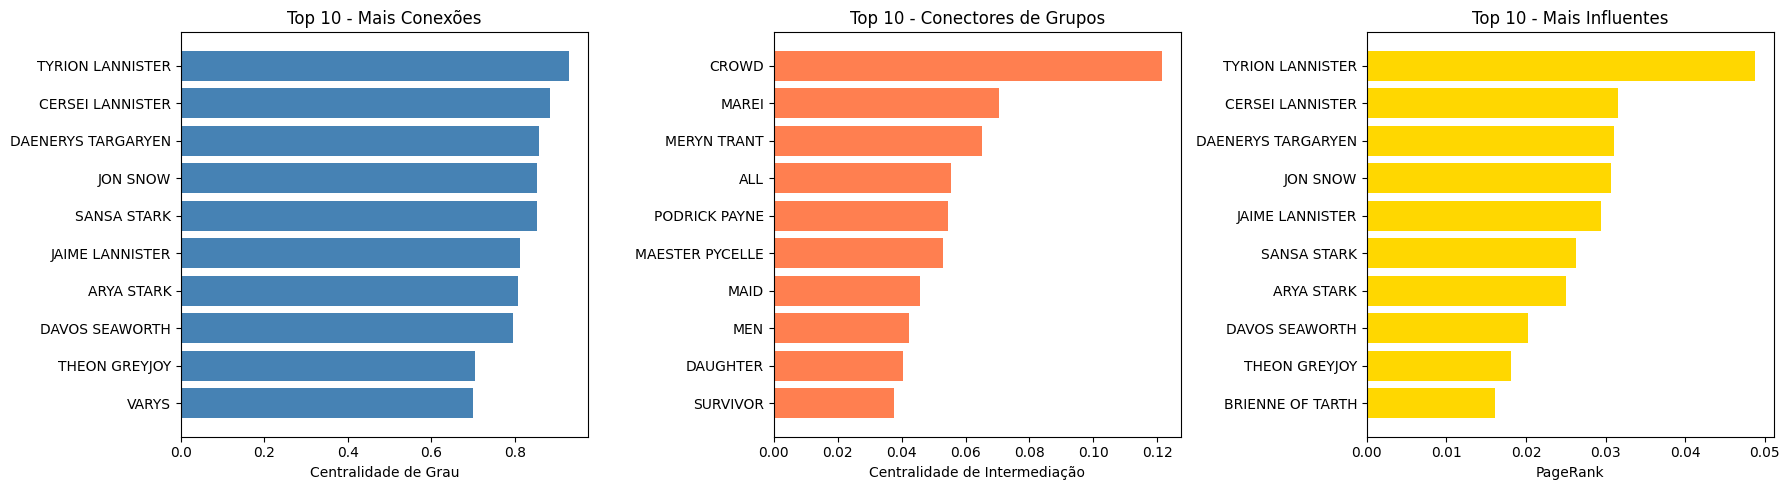

In [ ]:
# Visualizar Top 10 por cada métrica
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top_n = 10

# Grau
top_degree = centrality_df.nlargest(top_n, 'Grau')
axes[0].barh(top_degree['Personagem'], top_degree['Grau'], color='steelblue')
axes[0].set_xlabel('Centralidade de Grau')
axes[0].set_title('Top 10 - Mais Conexões')
axes[0].invert_yaxis()

# Intermediação
top_between = centrality_df.nlargest(top_n, 'Intermediacao')
axes[1].barh(top_between['Personagem'], top_between['Intermediacao'], color='coral')
axes[1].set_xlabel('Centralidade de Intermediação')
axes[1].set_title('Top 10 - Conectores de Grupos')
axes[1].invert_yaxis()

# PageRank
top_pagerank = centrality_df.nlargest(top_n, 'PageRank')
axes[2].barh(top_pagerank['Personagem'], top_pagerank['PageRank'], color='gold')
axes[2].set_xlabel('PageRank')
axes[2].set_title('Top 10 - Mais Influentes')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

### 2. Detecção de Comunidades

Identificar grupos de poder (famílias, alianças):

In [ ]:
from networkx.algorithms import community

# Detectar comunidades usando Louvain
communities = community.greedy_modularity_communities(G, weight='weight')

print(f'Número de comunidades detectadas: {len(communities)}\n')

# Mostrar as 5 maiores comunidades
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5]):
    print(f'\nComunidade {i+1} ({len(comm)} membros):')
    print(', '.join(sorted(list(comm))[:15]))  # Primeiros 15 membros

Número de comunidades detectadas: 7


Comunidade 1 (134 membros):
A VOICE, AERON, AERSON, ALLISER THORNE, ANNOUNCER, AREO HOTAH, ARTHUR, ATTENDANT, AXELL FLORENT, BALON DWARF, BANKER, BARRISTAN SELMY, BIANCA, BLACK HAIRED PROSTITUTE, BLONDE PROSTITUTE

Comunidade 2 (118 membros):
AHSA, ALL THREE, ALTON LANNISTER, AMORY LORCH, ANGUY, ARMORY, BALON GREYJOY, BITER, BLACK LORREN, BLACKFISH, BLACKSMITH, BOLTON GUARD, CATELYN STARK, COLEN, COOPER

Comunidade 3 (111 membros):
ALL, ALL TOGETHER, ARCHERS, ARYA STARK, BELICHO, BENJEN STARK, BERIC DONDARRION, BLACK WALDER RIVERS, BOLTON BANNERMAN, BOTH, BRAN STARK, BRAN'S VOICE, BRIENNE OF TARTH, BRONN, BRYNDEN TULLY

Comunidade 4 (10 membros):
ELDER MEEREEN SLAVE, KARL TANNER, KNIGHT, LYSA ARRYN, MEERA REED, MEEREEN SLAVE, MORAG, SISSY, SLAVES, WOMEN

Comunidade 5 (3 membros):
GARED, WAYMAR ROYCE, WILL


## 📊 Resposta à Pergunta de Negócio

### "Matematicamente, quem é o personagem mais importante?"

Baseado nas métricas calculadas:

1. **PageRank** (influência global): Identifica quem tem conexões com personagens importantes
2. **Centralidade de Grau**: Quem tem mais conexões diretas
3. **Centralidade de Intermediação**: Quem conecta diferentes grupos

O personagem no topo do ranking é o **mais importante matematicamente**.

In [ ]:
# Personagem mais importante
most_important = centrality_df.iloc[0]

print('=' * 60)
print('PERSONAGEM MAIS IMPORTANTE DE GAME OF THRONES')
print('=' * 60)
print(f'\n🏆 {most_important["Personagem"]}\n')
print(f'PageRank: {most_important["PageRank"]:.4f}')
print(f'Centralidade de Grau: {most_important["Grau"]:.4f}')
print(f'Centralidade de Intermediação: {most_important["Intermediacao"]:.4f}')
print('\n' + '=' * 60)

PERSONAGEM MAIS IMPORTANTE DE GAME OF THRONES

🏆 TYRION LANNISTER

PageRank: 0.0487
Centralidade de Grau: 0.9289
Centralidade de Intermediação: 0.0002



In [ ]:
df_interacoes = pd.read_csv('dataset_interacoes_personagens.csv')
df_interacoes

C:\Users\carlo\AppData\Local\Temp\ipykernel_3820\196070790.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_interacoes = pd.read_csv('dataset_interacoes_personagens.csv')


,temporada,episodio,cena,descricao_cena,falante_oficial,ouvinte_oficial,fala,tamanho_fala,num_personagens_cena,tipo_interacao
0,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,WILL,What d’you expect? They’re savages. One lot st...,136,4,group
1,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,YOHN ROYCE,What d’you expect? They’re savages. One lot st...,136,4,group
2,1,1,0,[First scene opens with three Rangers riding t...,WAYMAR ROYCE,GARED,What d’you expect? They’re savages. One lot st...,136,4,group
3,1,1,0,[First scene opens with three Rangers riding t...,WILL,WAYMAR ROYCE,I’ve never seen wildlings do a thing like this...,103,4,group
4,1,1,0,[First scene opens with three Rangers riding t...,WILL,YOHN ROYCE,I’ve never seen wildlings do a thing like this...,103,4,group
...,...,...,...,...,...,...,...,...,...,...
585385,8,6,0,NaN,ALL,DAVOS SEAWORTH,The Queen in the North! The Queen in the North...,119,22,group
585386,8,6,0,NaN,ALL,ROBIN ARRYN,The Queen in the North! The Queen in the North...,119,22,group
585387,8,6,0,NaN,ALL,BRONN,The Queen in the North! The Queen in the North...,119,22,group
585388,8,6,0,NaN,ALL,MAESTER WOLKAN,The Queen in the North! The Queen in the North...,119,22,group


In [ ]:

df_interacoes[df_interacoes['num_personagens_cena'] == 2].count()


temporada               640
episodio                640
cena                    640
descricao_cena          640
falante_oficial         640
ouvinte_oficial         640
fala                    640
tamanho_fala            640
num_personagens_cena    640
tipo_interacao          640
dtype: int64

In [ ]:
df_interacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585390 entries, 0 to 585389
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   temporada             585390 non-null  int64 
 1   episodio              585390 non-null  int64 
 2   cena                  585390 non-null  int64 
 3   descricao_cena        1699 non-null    object
 4   falante_oficial       585390 non-null  object
 5   ouvinte_oficial       585390 non-null  object
 6   fala                  585369 non-null  object
 7   tamanho_fala          585390 non-null  int64 
 8   num_personagens_cena  585390 non-null  int64 
 9   tipo_interacao        585390 non-null  object
dtypes: int64(5), object(5)
memory usage: 44.7+ MB


In [ ]:
print(f'Total de interações: {len(df_interacoes):,}')
print(f'Personagens únicos (falantes): {df_interacoes.falante_oficial.nunique()}')
print(f'Personagens únicos (ouvintes): {df_interacoes.ouvinte_oficial.nunique()}')

Total de interações: 585,390
Personagens únicos (falantes): 381
Personagens únicos (ouvintes): 381
